#PROBLEM STATEMENT:

Recruitment companies and organizations often face challenges in determining an appropriate salary for a job position. Salary depends on several factors such as job role, experience level, required skills, company size, location, industry, employment type, remote work, and benefits.

The objective of this project is to develop a Machine Learning regression model that predicts the expected salary of a job in USD based on its job-related, company-related, and candidate-related attributes. The project will analyze historical job data to identify salary patterns and use KNN Regression to estimate the salary of new job positions based on similar jobs in the dataset.

In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("/content/ai_job_dataset.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [4]:
df['posting_date'] = pd.to_datetime(df['posting_date'])
df['application_deadline'] = pd.to_datetime(df['application_deadline'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   job_id                  15000 non-null  object        
 1   job_title               15000 non-null  object        
 2   salary_usd              15000 non-null  int64         
 3   salary_currency         15000 non-null  object        
 4   experience_level        15000 non-null  object        
 5   employment_type         15000 non-null  object        
 6   company_location        15000 non-null  object        
 7   company_size            15000 non-null  object        
 8   employee_residence      15000 non-null  object        
 9   remote_ratio            15000 non-null  int64         
 10  required_skills         15000 non-null  object        
 11  education_required      15000 non-null  object        
 12  years_experience        15000 non-null  int64 

numerical columns:
salary_usd,remote_ratio,years_Exp,job_description_length,benefits_score

-categorical columns:
-job_title
experience_level
employment_type
company_location
company_size
company_name
employee_residence
education_required
required_skills
industry
salary_currency
job_id
  

-date columns
-posting_date
application_deadline


In [6]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [7]:
df.isnull().sum()

,0
job_id,0
job_title,0
salary_usd,0
salary_currency,0
experience_level,0
employment_type,0
company_location,0
company_size,0
employee_residence,0
remote_ratio,0


zero missing values

In [8]:
df.duplicated().sum()

np.int64(0)

zero duplicate values

In [9]:
df.describe()

,salary_usd,remote_ratio,years_experience,posting_date,application_deadline,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000,15000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,2024-08-29 08:48:51.840000,2024-10-11 21:55:23.520000,1503.314733,7.504273
min,32519.000000,0.000000,0.000000,2024-01-01 00:00:00,2024-01-16 00:00:00,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,2024-04-29 00:00:00,2024-06-13 00:00:00,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,2024-08-28 00:00:00,2024-10-12 00:00:00,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2024-12-29 00:00:00,2025-02-10 00:00:00,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2025-04-30 00:00:00,2025-07-11 00:00:00,2499.000000,10.000000
std,60260.940438,40.812712,5.545768,NaN,NaN,576.127083,1.450870


we need visualization bcz to understand-

-Distribution → Where are most values concentrated?
Example: Are most salaries ₹3–8 LPA or ₹10–20 LPA?

Skewness → Is the data balanced or pulled toward one side?
Example: Most salaries are low, but a few are extremely high.
Outliers → Are there unusual values?
Example: Most experience is 1–10 years, but one person has 40 years.

Relationships → Are two variables related?
Example: Does salary increase as experience increases?

Category differences → Which categories have higher/lower values?
Example: Do different job roles have different salary levels?

Spread/range → How much do values vary?
Example: Experience ranges from 0–20 years, while salary ranges from ₹2–50 LPA.

In one simple sentence:

We use visualization in EDA to see patterns, distributions, relationships, unusual values, and differences in our data that may not be easy to understand just by looking at raw numbers.

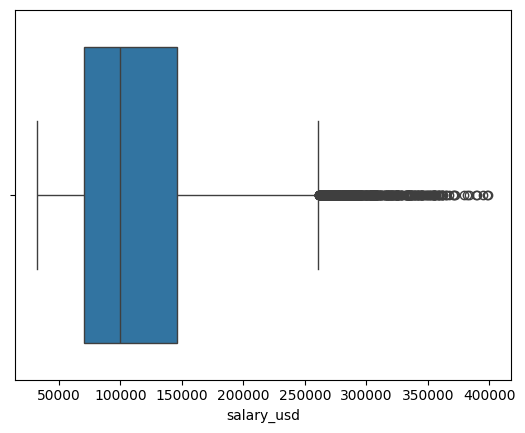

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(df,x="salary_usd")
plt.show()

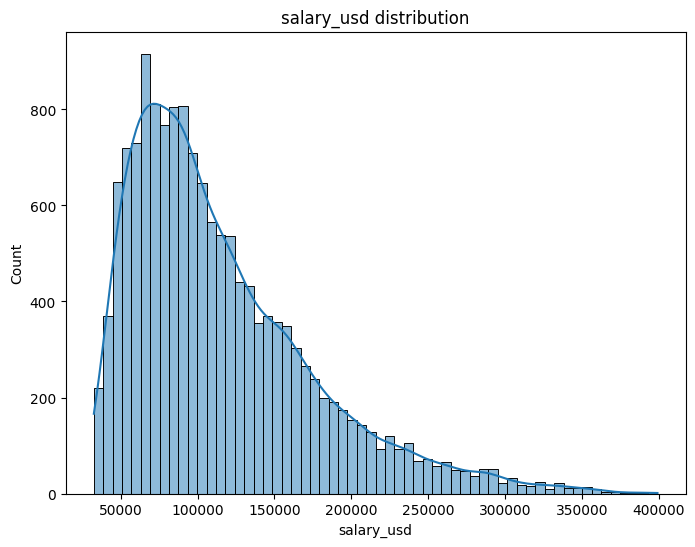

In [11]:
plt.figure(figsize=(8,6))
sns.histplot(df,x="salary_usd",kde=True)
plt.title("salary_usd distribution")
plt.show()

salary_usd is positively (right) skewed, indicating that most job salaries are concentrated in the lower-to-middle salary range, while a smaller number of high-paying jobs extend the distribution toward higher salary values.

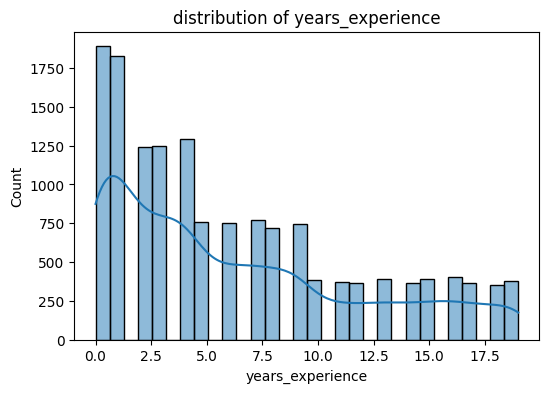

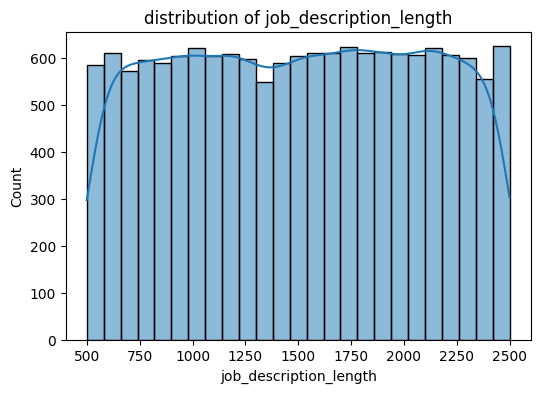

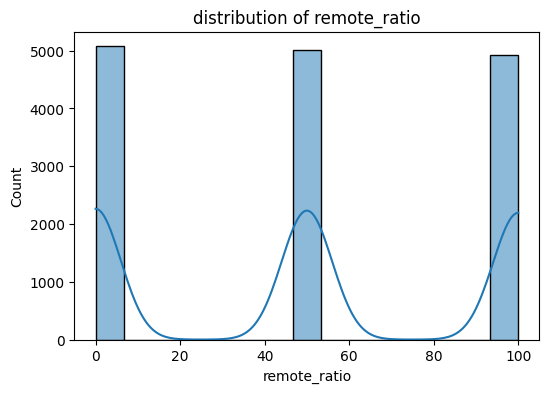

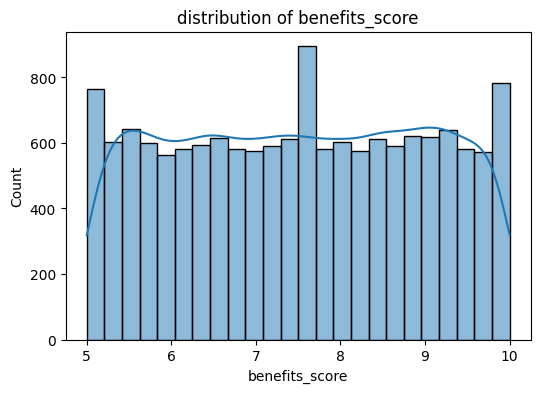

In [12]:
numeric_cols=[
    "years_experience",
    "job_description_length",
    "remote_ratio",
    "benefits_score"
]
for col in numeric_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col],kde=True)
  plt.title(f'distribution of {col}')
  plt.show()

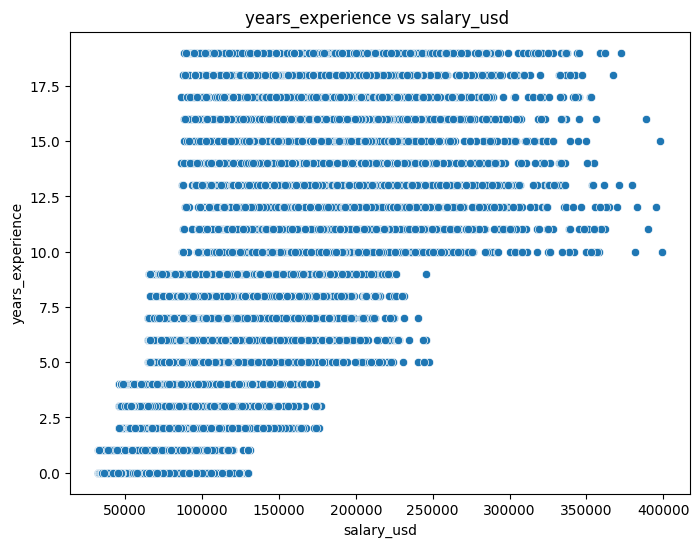

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(df,
                x="salary_usd",
                y="years_experience")
plt.title("years_experience vs salary_usd ")
plt.show()

high experince high salary

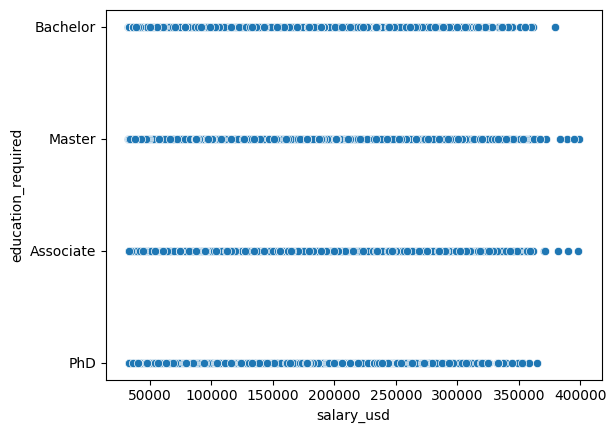

In [14]:
sns.scatterplot(df,x="salary_usd",y="education_required")
plt.show()

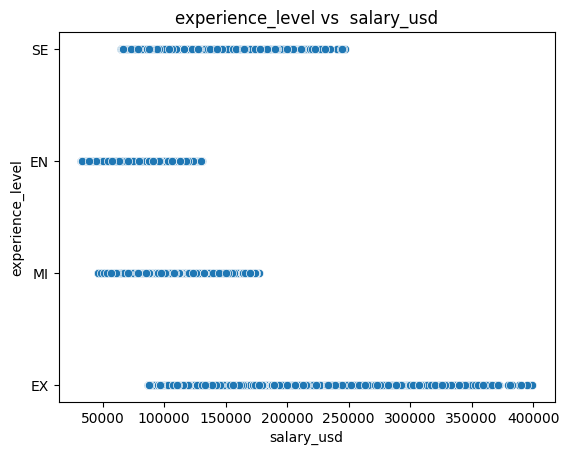

In [15]:
sns.scatterplot(df,x="salary_usd",y="experience_level")
plt.title("experience_level vs  salary_usd")
plt.show()

salary is differed between entry,mid-level,senior,executive level

-executive have high salary

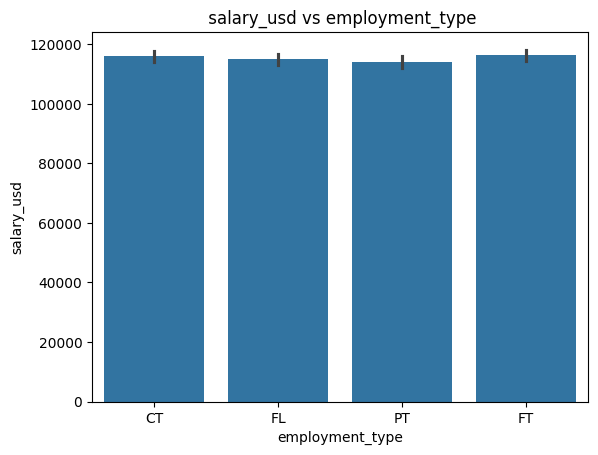

In [16]:
sns.barplot(df,x="employment_type",y="salary_usd")
plt.title(" salary_usd vs employment_type")
plt.show()

all employment_type has same salary

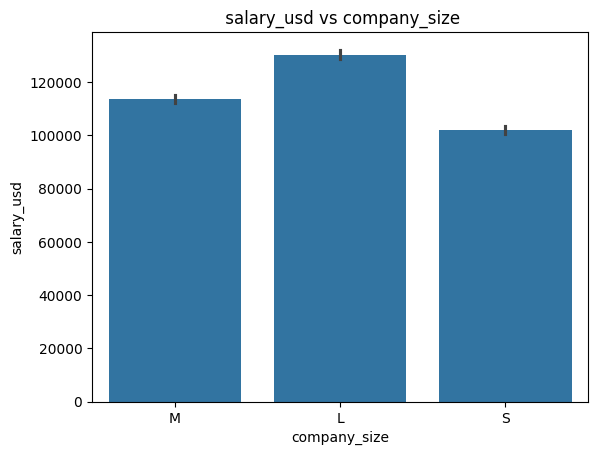

In [17]:
sns.barplot(df,x="company_size",y="salary_usd")
plt.title(" salary_usd vs company_size")
plt.show()

large company size has high salaries

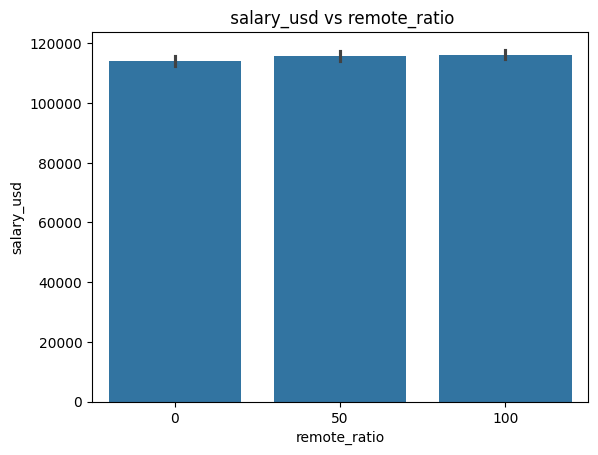

In [18]:
sns.barplot(df,x="remote_ratio",y="salary_usd")
plt.title(" salary_usd vs remote_ratio")
plt.show()

there is no differece between range 0 -100 remote ratio

-same salaries

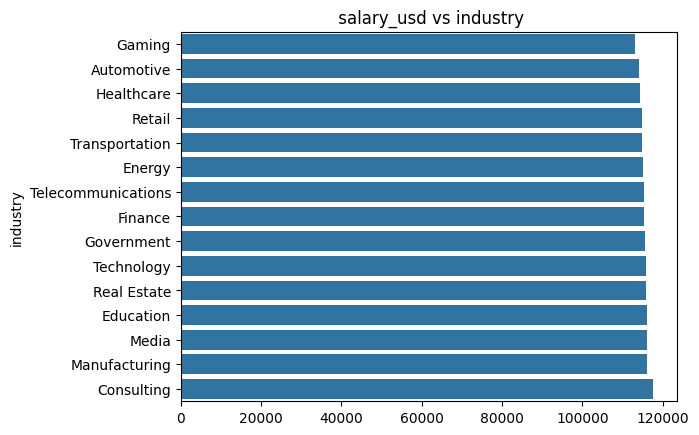

In [19]:
industry_salary=df.groupby("industry")["salary_usd"].mean().sort_values()
sns.barplot(x=industry_salary.values,y=industry_salary.index)
plt.title(" salary_usd vs industry")
plt.show()

consulting has small difference of salary compared to others

- it has high salary

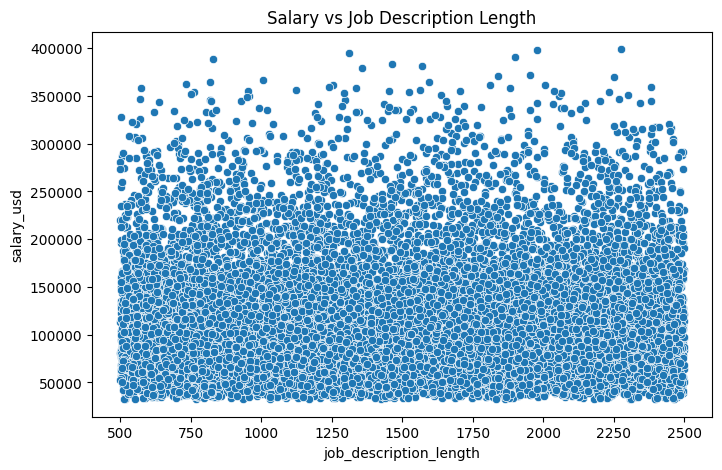

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(df,x="job_description_length",y="salary_usd")
plt.title("Salary vs Job Description Length")
plt.show()

-so there is no much difference between salary vs job description length

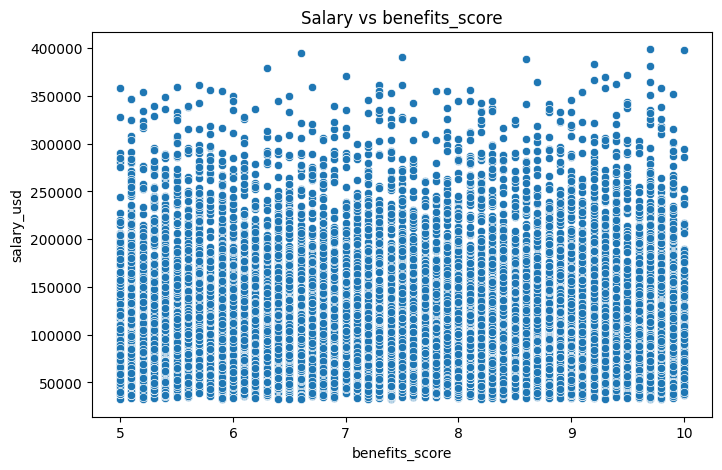

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(df,x="benefits_score",y="salary_usd")
plt.title("Salary vs benefits_score")
plt.show()

- no relationship between salary and benefit_Score

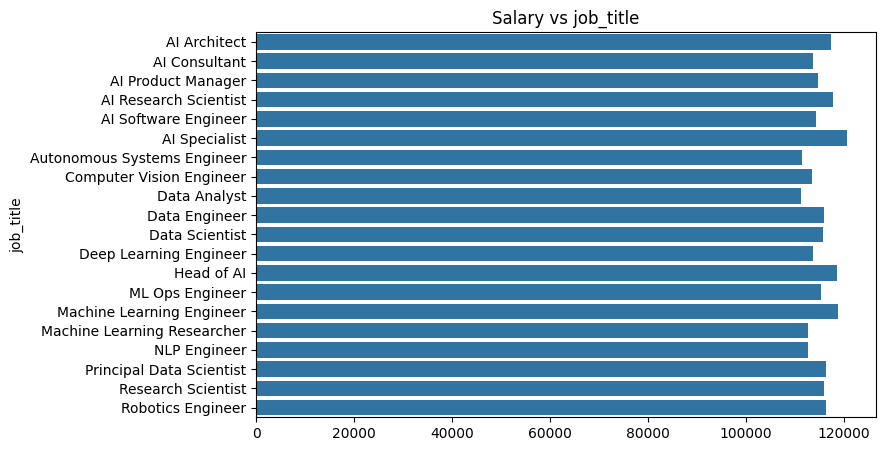

In [22]:
job_salary=(df.groupby("job_title")["salary_usd"].mean())
plt.figure(figsize=(8,5))
sns.barplot(x=job_salary.values,y=job_salary.index)
plt.title("Salary vs job_title")
plt.show()

-Ai specialist has high salary compared to other job_titles

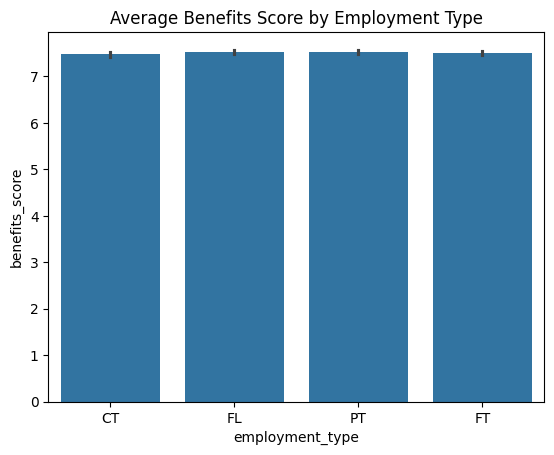

In [23]:
sns.barplot(df,
    x='employment_type',
    y='benefits_score')

plt.title('Average Benefits Score by Employment Type')
plt.show()

-almost all employment_type has equal benefit score

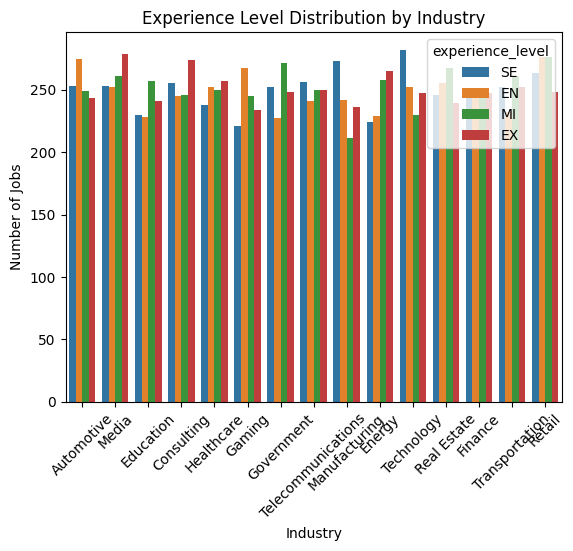

In [24]:
sns.countplot(df,x="industry",hue="experience_level")
plt.title('Experience Level Distribution by Industry')
plt.xlabel('Industry')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45)
plt.show()

-so each industry has its own seperte experience level

-some industries have more jobs for SE and some have EX

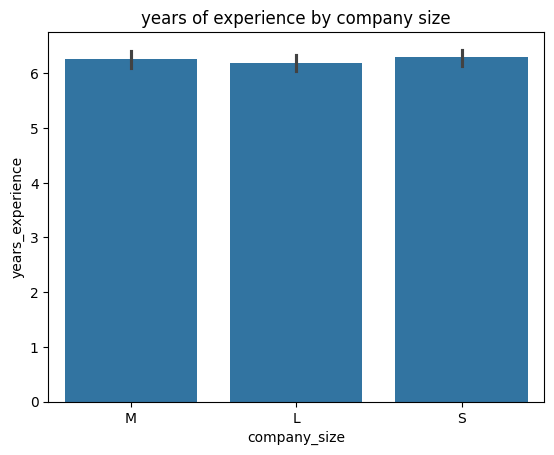

In [25]:
sns.barplot(df,x="company_size",y="years_experience")
plt.title("years of experience by company size")
plt.show()

-there is just slight difference between L company size slightly less has others

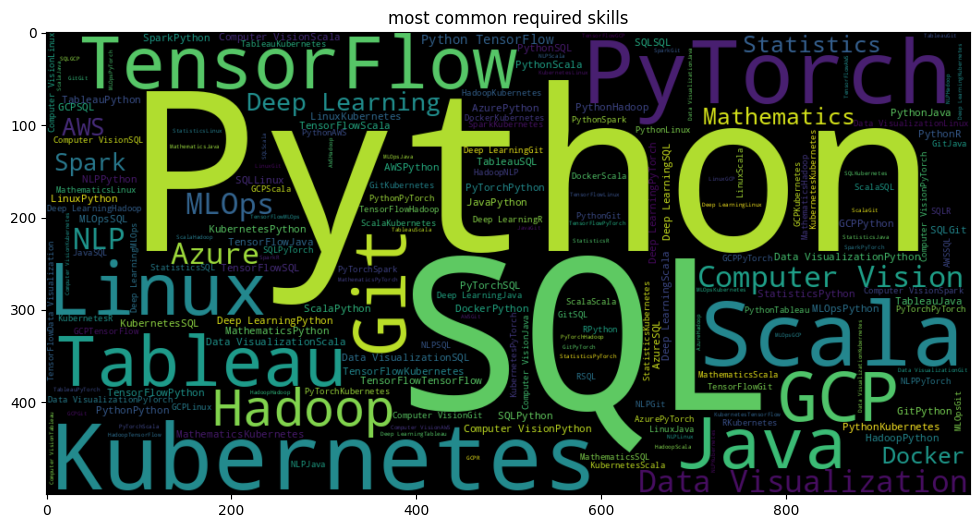

In [26]:
from wordcloud import WordCloud
text="".join(df["required_skills"].dropna().astype(str))
wordcloud=WordCloud( width=1000,
    height=500,).generate(text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud,interpolation="bilinear")
plt.title("most common required skills")
plt.show()

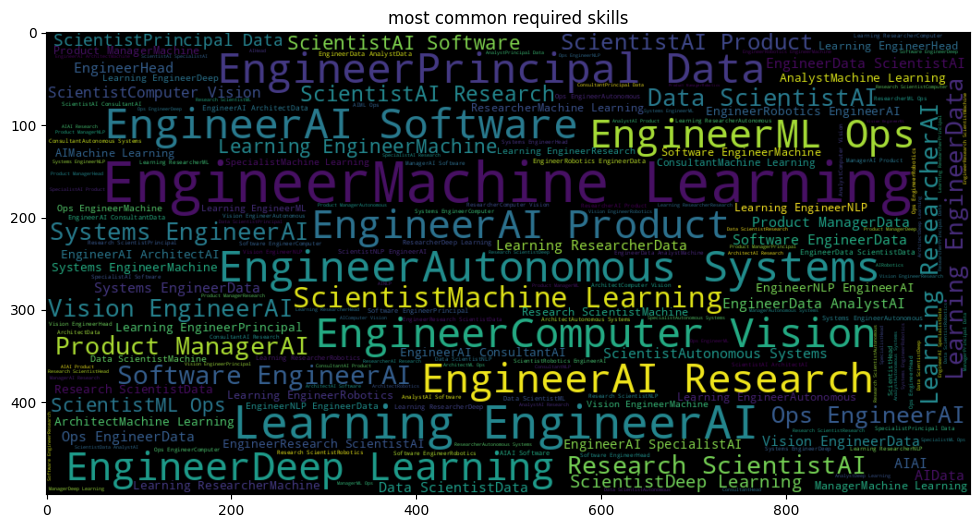

In [27]:
from wordcloud import WordCloud
text="".join(df["job_title"].dropna().astype(str))
wordcloud=WordCloud( width=1000,
    height=500,).generate(text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud,interpolation="bilinear")
plt.title("most common required skills")
plt.show()

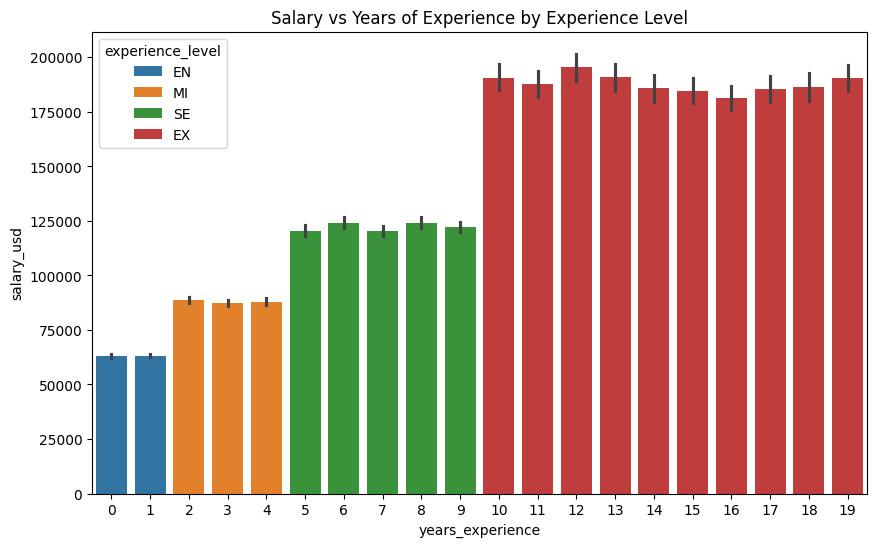

In [28]:
plt.figure(figsize=(10,6))
sns.barplot(df,x="years_experience",y="salary_usd",hue="experience_level")
plt.title("Salary vs Years of Experience by Experience Level")
plt.show()

- ex level and more experience has high salary than others

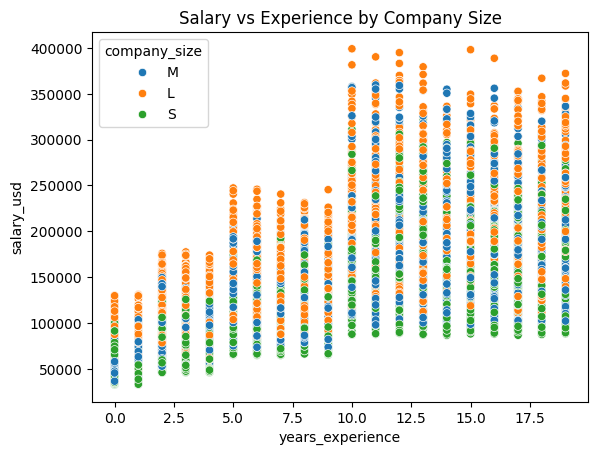

In [29]:
sns.scatterplot(df,x='years_experience',y='salary_usd',hue='company_size'
)
plt.title('Salary vs Experience by Company Size')
plt.show()

-large companysize with less experience less salary and more years_experience high salary

--same for all company size

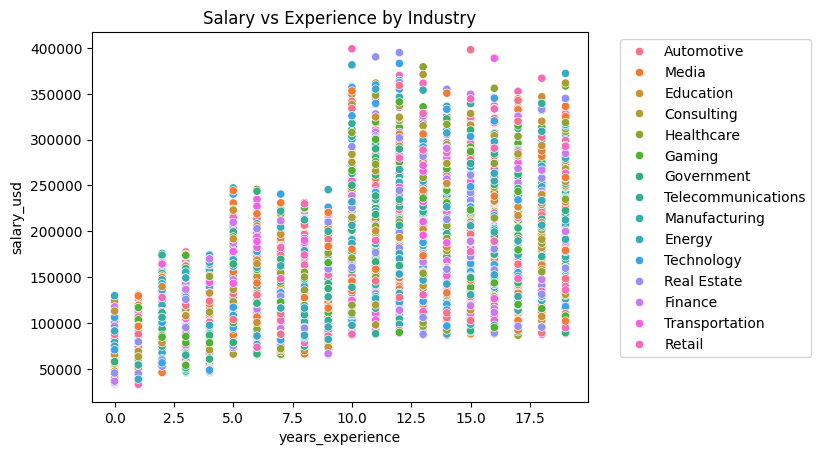

In [30]:
sns.scatterplot(df, x='years_experience',y='salary_usd',
    hue='industry'
)
plt.title('Salary vs Experience by Industry')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

-each industry with high year_experience have high salary

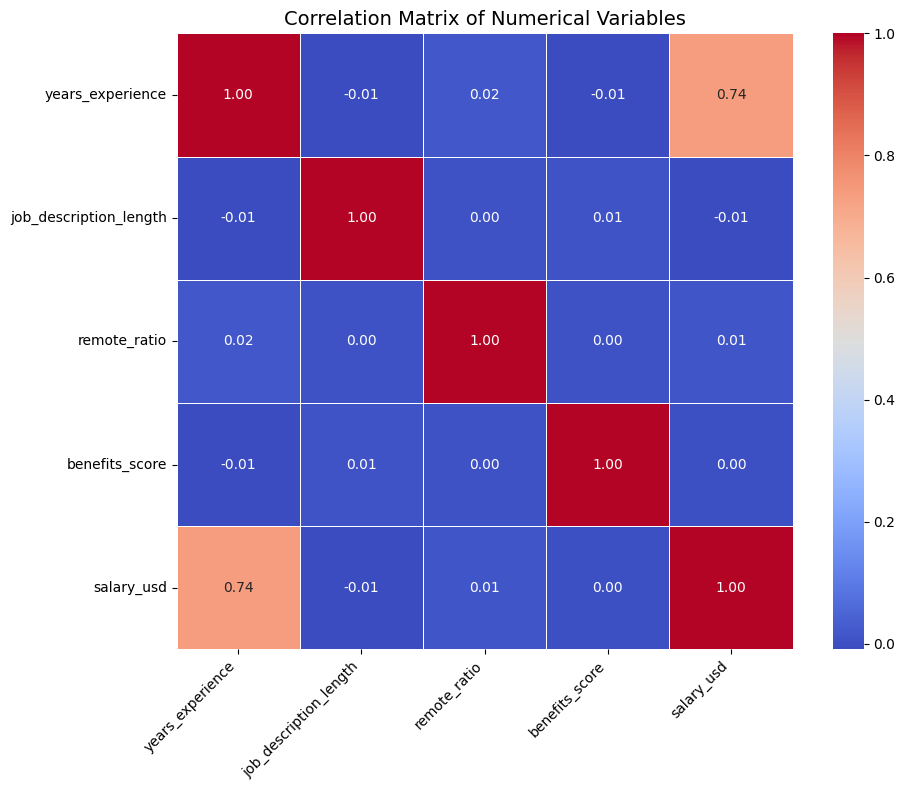

In [31]:
numeric_cols = [
    'years_experience',
    'job_description_length',
    'remote_ratio',
    'benefits_score',
    'salary_usd'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)

plt.title('Correlation Matrix of Numerical Variables', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#FEATURE ENGINEERING

In [32]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   job_id                  15000 non-null  object        
 1   job_title               15000 non-null  object        
 2   salary_usd              15000 non-null  int64         
 3   salary_currency         15000 non-null  object        
 4   experience_level        15000 non-null  object        
 5   employment_type         15000 non-null  object        
 6   company_location        15000 non-null  object        
 7   company_size            15000 non-null  object        
 8   employee_residence      15000 non-null  object        
 9   remote_ratio            15000 non-null  int64         
 10  required_skills         15000 non-null  object        
 11  education_required      15000 non-null  object        
 12  years_experience        15000 non-null  int64 

In [34]:
df['posting_date'] = pd.to_datetime(df['posting_date'])
df['application_deadline'] = pd.to_datetime(df['application_deadline'])

df['posting_year'] = df['posting_date'].dt.year
df['posting_month'] = df['posting_date'].dt.month


In [35]:
df['application_window'] = (
    df['application_deadline'] - df['posting_date']
).dt.days

In [36]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,...,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name,posting_year,posting_month,application_window
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,...,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics,2024,10,20
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,...,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc,2024,11,52
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,...,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech,2025,3,20
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,...,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems,2024,12,63
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,...,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics,2025,4,69


In [42]:
df.columns

Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name', 'posting_year', 'posting_month', 'application_window'],
      dtype='object')